# ML-10 — Content Action Playbook

## Purpose

This notebook turns the validated content-opportunity model output into a practical
content action playbook.

The output is a ranked review queue, not an automatic publishing system.

The playbook answers:

- Which pages should a reviewer look at first?
- Why was each page ranked highly?
- What action should be considered?
- Which pages need stronger human review?
- When should the scoring system be monitored or retrained?
- What should never be automated?

## Project lane

Refresh / Content Opportunity Scoring.

## Decision principle

The model supports prioritization.

It does not prove that a page will recover after a refresh, and it does not prove
that a particular content change caused a performance improvement.

All recommendations are therefore treated as decision-support and require human review.

## Setup

The notebook uses the existing project files rather than creating a separate modeling
pipeline.

The main source is the anonymized content-refresh dataset and the existing model
outputs produced by the earlier modeling/validation work.

The notebook also creates the required `work/outputs/` directory if it does not exist.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Project paths
PROJECT_ROOT = Path("..").resolve().parent
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "content_refresh_anonymized.csv"
OUTPUT_DIR = PROJECT_ROOT / "work" / "outputs"
FIGURE_DIR = PROJECT_ROOT / "work" / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data exists:", DATA_PATH.exists())
print("Output directory:", OUTPUT_DIR)

Project root: C:\Users\Ashok\Desktop\Mayur\internship-local-project\Internship-starter-flyrank
Data exists: True
Output directory: C:\Users\Ashok\Desktop\Mayur\internship-local-project\Internship-starter-flyrank\work\outputs


In [2]:
Path("..").resolve().parent

WindowsPath('C:/Users/Ashok/Desktop/Mayur/internship-local-project/Internship-starter-flyrank')

## Source data

The starter refresh dataset contains observable content and search-performance signals.

The core feature window includes measures such as:

- impressions
- sessions
- content age
- freshness
- CTR
- average position
- engagement
- scroll behaviour
- content depth

The starter target was whether `trend_direction == "down"`.

This target is a proxy for decline risk. It should not be interpreted as proof that
a page will decline in the future or that a refresh will cause recovery.

In [3]:
df = pd.read_csv(DATA_PATH)

print("Rows:", len(df))
print("Columns:", len(df.columns))

display(df.head())

Rows: 30000
Columns: 44


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


## Column check

Before constructing the action queue, check which fields are actually available.

This prevents the playbook from depending on columns that are not present in the
current dataset.

In [4]:
print("Available columns:")
for col in df.columns:
    print("-", col)

Available columns:
- content_id
- client_id
- search_volume
- competition
- competition_level
- cpc
- content_type
- main_intent
- word_count
- char_count
- provider_used
- model_used
- impressions_90d
- clicks_90d
- pageviews_90d
- sessions_90d
- users_90d
- engaged_sessions_90d
- ai_sessions_90d
- scroll_events_90d
- days_with_impressions
- days_with_sessions
- impressions_last_30d
- clicks_last_30d
- sessions_last_30d
- impressions_prev_30d
- clicks_prev_30d
- sessions_prev_30d
- content_age_days
- age_tier
- age_tier_order
- days_since_last_update
- freshness_tier
- word_count_tier
- char_count_tier
- ctr
- avg_position
- engagement_rate
- scroll_rate
- ai_traffic_pct
- impression_tier
- position_tier
- trend_direction
- trend_pct


## Existing validated output

The action playbook should consume the validated model output from the previous
modeling and validation work.

The preferred source is the existing refresh queue/model output.

If a complete queue is already available, this notebook uses it rather than silently
training a different model.

This keeps the action playbook aligned with the validated model.

In [5]:
candidate_files = [
    OUTPUT_DIR / "refresh_queue.csv",
    OUTPUT_DIR / "refresh_queue_sample.csv",
    PROJECT_ROOT / "outputs" / "refresh_queue.csv",
    PROJECT_ROOT / "outputs" / "refresh_queue_sample.csv",
]

existing_queue = None
queue_path = None

for path in candidate_files:
    if path.exists():
        try:
            existing_queue = pd.read_csv(path)
            queue_path = path
            print("Using queue:", path)
            print("Rows:", len(existing_queue))
            break
        except Exception as e:
            print("Could not read:", path, "|", e)

if existing_queue is None:
    print("No existing refresh queue found.")

Using queue: C:\Users\Ashok\Desktop\Mayur\internship-local-project\Internship-starter-flyrank\outputs\refresh_queue_sample.csv
Rows: 200


## Validated model context

The previously validated starter comparison was:

| Method | ROC-AUC | Average Precision | Precision@50 |
|---|---:|---:|---:|
| Baseline rules | 0.627 | 0.468 | 0.240 |
| Logistic regression | 0.700 | 0.522 | 0.400 |
| Decision tree | 0.742 | 0.575 | 0.540 |
| Random forest | 0.750 | 0.618 | 0.740 |

The random forest was the strongest ranking method on this starter slice.

Precision@50 of 0.740 means approximately 37 of the top 50 pages were positive
under the chosen proxy label in that validation result.

This is evidence of useful ranking performance on that slice, not evidence that
37 pages will benefit from a refresh.

In [6]:
model_results_path_candidates = [
    OUTPUT_DIR / "model_results.json",
    PROJECT_ROOT / "outputs" / "model_results.json",
]

model_results = None

for path in model_results_path_candidates:
    if path.exists():
        with open(path, "r", encoding="utf-8") as f:
            model_results = json.load(f)
        print("Loaded:", path)
        break

if model_results is None:
    print("No model_results.json found; using the validated metrics documented above.")

No model_results.json found; using the validated metrics documented above.


# 1. Ranked actions + reason codes

The queue ranks pages for human review.

A high score means the page deserves earlier attention based on the available
observable signals.

It does not mean:

- the page is guaranteed to decline,
- a refresh is guaranteed to work,
- the model knows the cause of the problem,
- or the recommended action should happen automatically.

Each queue row therefore includes:

1. rank
2. score
3. model probability where available
4. action
5. reason codes
6. confidence
7. review notes

In [7]:
def add_reason_codes(row):
    reasons = []

    def val(name, default=np.nan):
        return row[name] if name in row.index else default

    impressions = val("impressions_90d")
    sessions = val("sessions_90d")
    age = val("content_age_days")
    days_update = val("days_since_last_update")
    word_count = val("word_count")
    position = val("avg_position")
    ctr = val("ctr")
    trend = val("trend_direction")
    engagement = val("engagement_rate")
    scroll = val("scroll_rate")
    model_prob = val("model_probability")

    if pd.notna(days_update) and pd.notna(impressions):
        if days_update >= 180 and impressions >= 500:
            reasons.append("stale_visible_page")

    if pd.notna(trend) and pd.notna(impressions):
        if trend == "down" and impressions >= 100:
            reasons.append("declining_with_demand")

    if pd.notna(word_count) and pd.notna(impressions):
        if 0 < word_count < 1200 and impressions >= 250:
            reasons.append("thin_visible_page")

    if pd.notna(position) and pd.notna(age):
        if 0 < position <= 10 and age >= 180:
            reasons.append("page_one_decay_risk")

    if pd.notna(impressions) and pd.notna(position) and pd.notna(ctr):
        if impressions >= 500 and 0 < position <= 20 and ctr < 0.5:
            reasons.append("low_ctr_visible_page")

    if pd.notna(sessions):
        engagement_problem = (
            (pd.notna(engagement) and engagement < 30)
            or
            (pd.notna(scroll) and scroll < 30)
        )

        if sessions >= 30 and engagement_problem:
            reasons.append("low_engagement_visible_page")

    if pd.notna(model_prob):
        if model_prob >= 0.65:
            reasons.append("model_decline_risk")

        if model_prob >= 0.50 and pd.notna(impressions):
            if impressions >= 500:
                reasons.append("visible_model_opportunity")

    return reasons


df["reason_code_list"] = df.apply(add_reason_codes, axis=1)

df["reason_codes"] = df["reason_code_list"].apply(
    lambda x: "|".join(x) if x else "no_primary_reason"
)

print(df["reason_codes"].value_counts().head(15))

reason_codes
no_primary_reason                                                                             8976
declining_with_demand                                                                         4416
declining_with_demand|low_ctr_visible_page                                                    2907
page_one_decay_risk                                                                           2474
declining_with_demand|low_engagement_visible_page                                             1726
low_ctr_visible_page                                                                          1390
low_engagement_visible_page                                                                   1374
declining_with_demand|page_one_decay_risk|low_ctr_visible_page                                1296
declining_with_demand|low_ctr_visible_page|low_engagement_visible_page                        1238
low_ctr_visible_page|low_engagement_visible_page                                               8

## Model score alignment

If the existing validated queue contains a model probability or final score,
preserve those values.

The action playbook adds interpretation around the validated score rather than
inventing a new predictive score.

In [8]:
if existing_queue is not None:
    print("Queue columns:")
    print(existing_queue.columns.tolist())

Queue columns:
['final_rank', 'content_id', 'client_id', 'final_refresh_score', 'best_model_name', 'best_model_probability', 'baseline_refresh_score', 'confidence', 'suggested_action', 'final_reason_codes', 'is_declining_label', 'impressions_90d', 'clicks_90d', 'sessions_90d', 'avg_position', 'ctr', 'content_age_days', 'days_since_last_update', 'word_count', 'trend_direction', 'competition_level', 'content_type', 'main_intent', 'age_tier', 'freshness_tier', 'word_count_tier', 'impression_tier', 'position_tier']


## Archetype → action mapping

The action is a review recommendation, not an automatic instruction.

The mapping uses observable patterns:

| Pattern / archetype | Primary action | Why |
|---|---|---|
| Stale visible page | Refresh | Existing visibility plus age suggests review value |
| Declining with demand | Refresh / investigate | Demand exists while movement is negative |
| Thin visible page | Expand | Visible content may warrant depth review |
| Page-one decay risk | Protect / refresh | Strong position but older content deserves attention |
| Low CTR visible page | Metadata/snippet review | Visibility exists but clicks appear weak |
| Low engagement page | Engagement review | Sessions exist but engagement signals are weak |
| Strong page without clear issue | Monitor/protect | Avoid unnecessary changes |
| Multiple competing pages | Consolidation review | Human must inspect related pages before merging |

In [9]:
def choose_action(row):
    reasons = set(row["reason_code_list"])

    if "low_ctr_visible_page" in reasons:
        return "metadata_review"

    if "low_engagement_visible_page" in reasons:
        return "engagement_review"

    if "declining_with_demand" in reasons and "stale_visible_page" in reasons:
        return "refresh"

    if "page_one_decay_risk" in reasons:
        return "protect_or_refresh"

    if "stale_visible_page" in reasons:
        return "refresh"

    if "thin_visible_page" in reasons:
        return "expand"

    if "declining_with_demand" in reasons:
        return "investigate_decline"

    if "visible_model_opportunity" in reasons:
        return "human_review"

    return "monitor"


df["suggested_action"] = df.apply(choose_action, axis=1)

display(
    df["suggested_action"]
    .value_counts()
    .rename_axis("action")
    .reset_index(name="pages")
)

,action,pages
0,metadata_review,9759
1,monitor,8976
2,investigate_decline,4416
3,engagement_review,3695
4,protect_or_refresh,3115
5,expand,34
6,refresh,5


## Confidence

Confidence is an evidence-strength label, not a probability that the recommended
action will succeed.

A higher confidence label requires stronger observable evidence.

The starter policy uses:

- score above the 80th percentile
- at least 500 impressions
- at least 10 sessions
- model probability at least 0.50

These are policy thresholds for review prioritization, not universal thresholds.

In [10]:
# Use an available score column if present.
score_candidates = [
    "final_refresh_score",
    "refresh_score",
    "score",
    "model_probability"
]

score_col = next((c for c in score_candidates if c in df.columns), None)

if score_col is None:
    print("No score column found in raw data.")
else:
    score_80 = df[score_col].quantile(0.80)

    def confidence_label(row):
        conditions = 0

        if pd.notna(row[score_col]) and row[score_col] >= score_80:
            conditions += 1

        if "impressions_90d" in row.index and pd.notna(row["impressions_90d"]):
            if row["impressions_90d"] >= 500:
                conditions += 1

        if "sessions_90d" in row.index and pd.notna(row["sessions_90d"]):
            if row["sessions_90d"] >= 10:
                conditions += 1

        if "model_probability" in row.index and pd.notna(row["model_probability"]):
            if row["model_probability"] >= 0.50:
                conditions += 1

        if conditions >= 4:
            return "high"
        elif conditions >= 2:
            return "medium"
        else:
            return "low"

    df["confidence"] = df.apply(confidence_label, axis=1)
    print(df["confidence"].value_counts())

No score column found in raw data.


## Ranked review queue

The queue is ordered by the validated score when available.

The first rows represent the pages that should receive review attention first,
subject to reviewer capacity and the human-review rules defined later.

The queue is not a publishing queue.

In [11]:
if score_col is not None:
    ranked_df = df.sort_values(
        by=score_col,
        ascending=False,
        na_position="last"
    ).copy()

    ranked_df.insert(0, "review_rank", range(1, len(ranked_df) + 1))
else:
    ranked_df = df.copy()
    ranked_df.insert(0, "review_rank", range(1, len(ranked_df) + 1))

print("Ranked rows:", len(ranked_df))

display(
    ranked_df[
        [
            c for c in [
                "review_rank",
                "content_id",
                score_col,
                "suggested_action",
                "reason_codes",
                "confidence"
            ]
            if c is not None and c in ranked_df.columns
        ]
    ].head(20)
)

Ranked rows: 30000


,review_rank,content_id,suggested_action,reason_codes
0,1,content_304f48230142,investigate_decline,declining_with_demand
1,2,content_a1fb4e703a9e,investigate_decline,declining_with_demand
2,3,content_9aa793d4d895,investigate_decline,declining_with_demand
3,4,content_331d6c4de07b,metadata_review,page_one_decay_risk|low_ctr_visible_page|low_e...
4,5,content_d99b7a2d90ca,engagement_review,declining_with_demand|low_engagement_visible_page
5,6,content_d4084a4bc775,metadata_review,declining_with_demand|low_ctr_visible_page
6,7,content_9a34b442b552,monitor,no_primary_reason
7,8,content_a63219c6e95a,monitor,no_primary_reason
8,9,content_5e6c160719bc,engagement_review,declining_with_demand|low_engagement_visible_page
9,10,content_c27558df2b0c,metadata_review,declining_with_demand|page_one_decay_risk|low_...


## Top-20 review

The top 20 rows are the first practical review set.

The reviewer should inspect whether:

- the reason code makes sense,
- the page has enough evidence to matter,
- the action is realistic,
- the decline is not simply seasonality,
- another page has absorbed demand,
- the signal is not just low-volume noise.

A top-ranked page can still be rejected by a human reviewer.

In [12]:
top20 = ranked_df.head(20).copy()

print("Top-20 action distribution:")
display(
    top20["suggested_action"]
    .value_counts()
    .rename_axis("action")
    .reset_index(name="count")
)

print("\nTop-20 reason-code distribution:")
reason_counts = (
    top20["reason_code_list"]
    .explode()
    .value_counts()
    .rename_axis("reason_code")
    .reset_index(name="count")
)

display(reason_counts)

Top-20 action distribution:


,action,count
0,metadata_review,6
1,monitor,5
2,investigate_decline,4
3,engagement_review,4
4,protect_or_refresh,1



Top-20 reason-code distribution:


,reason_code,count
0,declining_with_demand,11
1,low_engagement_visible_page,8
2,page_one_decay_risk,6
3,low_ctr_visible_page,6


# 2. Intended use and limits

## Intended use

This playbook is intended for a content strategist, SEO analyst, or reviewer who
needs to prioritize a limited number of pages for investigation.

The main use is:

> rank pages so that human review time is spent first on pages with stronger
> observable evidence of decline, visibility, freshness, CTR, engagement, or
> content-depth opportunity.

The output is decision-support.

It can help a reviewer decide where to look first and which issue to investigate.

## What the model can support

The model can support:

- prioritizing review candidates;
- identifying pages with multiple risk/opportunity signals;
- grouping candidates by likely review action;
- making the reason for a ranking visible;
- allocating limited review capacity.

## What the model cannot establish

The model cannot establish that:

- a page will definitely decline;
- a page will definitely recover after a refresh;
- a refresh will cause more traffic;
- one particular content change caused a performance improvement;
- a ranking factor is a confirmed search-engine algorithm factor.

The available data is observational. A causal claim would require an experiment
or another valid causal design.

## Scope limits

The validated starter result came from a 30,000-row anonymized starter slice and
client-holdout validation.

It is not a benchmark for the full warehouse.

The model should therefore be described as useful evidence from the evaluated slice,
not as a universally validated production model.

In [13]:
summary = {
    "queue_rows": int(len(ranked_df)),
    "top_20_rows": int(min(20, len(ranked_df))),
    "score_column": score_col if score_col else "not_available",
    "model_probability_available": "model_probability" in ranked_df.columns,
    "reason_codes_available": "reason_codes" in ranked_df.columns,
    "suggested_actions_available": "suggested_action" in ranked_df.columns,
}

display(pd.DataFrame([summary]))

,queue_rows,top_20_rows,score_column,model_probability_available,reason_codes_available,suggested_actions_available
0,30000,20,not_available,False,True,True


# 3. Human review + the no-go list

## Human review is mandatory

The queue is a prioritization aid. A person must review a candidate before taking
a content action.

### Reviewer checklist

Before approving an action, check:

1. Is the signal large enough to matter?
2. Is there enough impressions/sessions evidence?
3. Is the movement persistent rather than a short fluctuation?
4. Could seasonality explain the change?
5. Could another related page have absorbed the demand?
6. Is there a technical or measurement explanation?
7. Does the suggested action match the actual content situation?
8. Is the page already performing well enough that changing it could create
   unnecessary risk?
9. Is the proposed change reversible or reviewable?
10. Is there a clear reason for the action?

## Special review for decline

A decline should not automatically be interpreted as a content problem.

The reviewer should distinguish:

- real decline,
- consolidation,
- seasonality,
- SERP/click behaviour changes,
- and noise.

The project guidance recommends checking earlier versus later windows, related
pages, site/topic trends, impressions, clicks, CTR, position, and volume before
calling a movement a real decline.

## Human override

A reviewer may reject, defer, or change the suggested action.

The model ranking does not override editorial judgment.

## No-go list: what should NOT be automated

The following decisions should remain human-controlled:

### 1. Automatic publishing

Do not automatically publish rewritten or refreshed content from the model score.

### 2. Automatic deletion

Do not automatically prune/delete a page because it receives a low score.

### 3. Automatic merging

Do not automatically merge pages.

A human must check whether two pages actually overlap and whether consolidation
would be appropriate.

### 4. Automatic canonical decisions

Do not automatically change canonical or indexing decisions from this score.

### 5. Automatic claim of causality

Do not automatically state that a refresh caused recovery.

The dataset does not provide a causal experiment.

### 6. Automatic search-engine claims

Do not turn the score into a claim about Google's ranking algorithm.

### 7. Automatic AI-search claims

Do not interpret sparse AI-referral measurements as proof of AI citations,
AI rankings, or AI visibility.

### 8. Automatic high-impact content changes

Major factual, legal, medical, financial, brand, or strategic changes require
human review regardless of score.

### 9. Automatic client-facing recommendations

The queue should not directly become a client-facing recommendation without
analyst review.

### 10. Automatic retraining

Do not retrain simply because the calendar says so.

Retraining should follow monitored evidence that the model or its input data
has materially changed.

## Human-review flags

The ranked queue is a decision-support tool.

A human reviewer must check each candidate before taking action.

The review flag identifies the type of check that should be performed before
acting on the recommendation.

The model score does not override human judgment.

In [ ]:
# Make sure required columns exist
if "reason_code_list" not in ranked_df.columns:
    ranked_df["reason_code_list"] = ranked_df["reason_codes"].fillna(
        "no_primary_reason"
    ).apply(
        lambda x: x.split("|") if isinstance(x, str) else []
    )

if "reason_codes" not in ranked_df.columns:
    ranked_df["reason_codes"] = ranked_df["reason_code_list"].apply(
        lambda x: "|".join(x) if x else "no_primary_reason"
    )


# Create confidence if it does not already exist
if "confidence" not in ranked_df.columns:

    # Find whichever score column is available
    available_score_cols = [
        "final_refresh_score",
        "refresh_score",
        "score",
        "model_probability"
    ]

    available_score = next(
        (col for col in available_score_cols if col in ranked_df.columns),
        None
    )

    if available_score is not None:

        score_values = pd.to_numeric(
            ranked_df[available_score],
            errors="coerce"
        )

        p80 = score_values.quantile(0.80)

        def make_confidence(row):

            evidence_count = 0

            # High relative score
            if pd.notna(row[available_score]):
                if row[available_score] >= p80:
                    evidence_count += 1

            # Enough impressions
            if "impressions_90d" in ranked_df.columns:
                if pd.notna(row["impressions_90d"]):
                    if row["impressions_90d"] >= 500:
                        evidence_count += 1

            # Enough sessions
            if "sessions_90d" in ranked_df.columns:
                if pd.notna(row["sessions_90d"]):
                    if row["sessions_90d"] >= 10:
                        evidence_count += 1

            # Model probability
            if "model_probability" in ranked_df.columns:
                if pd.notna(row["model_probability"]):
                    if row["model_probability"] >= 0.50:
                        evidence_count += 1

            if evidence_count >= 4:
                return "high"
            elif evidence_count >= 2:
                return "medium"
            else:
                return "low"

        ranked_df["confidence"] = ranked_df.apply(
            make_confidence,
            axis=1
        )

    else:
        # If there is no score at all, use a conservative label
        ranked_df["confidence"] = "review_required"



def review_flag(row):

    reasons = set(row["reason_code_list"])

    flags = []

    if "declining_with_demand" in reasons:
        flags.append("check_persistence")

    if "stale_visible_page" in reasons:
        flags.append("check_content_age")

    if "page_one_decay_risk" in reasons:
        flags.append("check_before_change")

    if "low_ctr_visible_page" in reasons:
        flags.append("check_position_context")

    if "low_engagement_visible_page" in reasons:
        flags.append("check_engagement_context")

    if "thin_visible_page" in reasons:
        flags.append("check_content_quality")

    if not flags:
        flags.append("standard_review")

    return "|".join(flags)


ranked_df["human_review_flag"] = ranked_df.apply(
    review_flag,
    axis=1
)


# Display top 20 safely


display_columns = [
    "review_rank",
    "suggested_action",
    "reason_codes",
    "confidence",
    "human_review_flag"
]

display_columns = [
    col for col in display_columns
    if col in ranked_df.columns
]

display(
    ranked_df[display_columns].head(20)
)

,review_rank,suggested_action,reason_codes,confidence,human_review_flag
0,1,investigate_decline,declining_with_demand,review_required,check_persistence
1,2,investigate_decline,declining_with_demand,review_required,check_persistence
2,3,investigate_decline,declining_with_demand,review_required,check_persistence
3,4,metadata_review,page_one_decay_risk|low_ctr_visible_page|low_e...,review_required,check_before_change|check_position_context|che...
4,5,engagement_review,declining_with_demand|low_engagement_visible_page,review_required,check_persistence|check_engagement_context
5,6,metadata_review,declining_with_demand|low_ctr_visible_page,review_required,check_persistence|check_position_context
6,7,monitor,no_primary_reason,review_required,standard_review
7,8,monitor,no_primary_reason,review_required,standard_review
8,9,engagement_review,declining_with_demand|low_engagement_visible_page,review_required,check_persistence|check_engagement_context
9,10,metadata_review,declining_with_demand|page_one_decay_risk|low_...,review_required,check_persistence|check_before_change|check_po...


# 4. Monitoring / retrain triggers

The action playbook should not be treated as permanently valid.

The underlying content inventory, traffic patterns, search behaviour, and feature
distributions can change.

Monitoring should therefore focus on:

- input drift;
- score drift;
- action mix drift;
- performance drift;
- reason-code drift;
- reviewer disagreement;
- data-quality failures.

## Monitoring principle

Do not retrain because the calendar says to retrain.

Retrain when monitored evidence suggests that the model is becoming less useful
for the decision it supports.

## Suggested monitoring / retrain triggers

### Trigger 1 — Input drift

Investigate if important feature distributions change materially.

Examples:

- impressions distribution changes;
- position distribution changes;
- content-age distribution changes;
- CTR distribution changes;
- content-type mix changes.

### Trigger 2 — Score drift

Investigate if the distribution of model scores changes substantially.

For example:

- unusually large increase in high-score pages;
- unusually large decrease in high-score pages.

### Trigger 3 — Queue composition drift

Investigate if the action mix changes sharply.

For example:

- nearly all pages become `refresh`;
- one reason code suddenly dominates;
- almost no pages receive an actionable reason.

### Trigger 4 — Precision@K deterioration

When future labels become available, recompute Precision@20 and Precision@50.

If Precision@50 falls materially below the previously validated result, investigate
before relying on the queue.

### Trigger 5 — Calibration/reliability deterioration

If model probabilities no longer correspond reasonably to observed outcomes,
review calibration.

### Trigger 6 — Data-quality failure

Stop using the queue if:

- required columns disappear;
- duplicate IDs increase unexpectedly;
- missingness changes sharply;
- feature windows overlap the target window;
- new leakage risks appear.

### Trigger 7 — Reviewer disagreement

If human reviewers frequently reject the suggested action or reason code,
investigate whether the decision rules still match the real workflow.

## Retrain condition

Retraining should require evidence of meaningful drift or deteriorating ranking
performance, followed by a fresh validation run.

A retrained model should not replace the existing model until the new validation
supports the change.

In [16]:
monitoring_summary = {}

if score_col and score_col in ranked_df.columns:
    monitoring_summary["score_mean"] = ranked_df[score_col].mean()
    monitoring_summary["score_median"] = ranked_df[score_col].median()
    monitoring_summary["score_p80"] = ranked_df[score_col].quantile(0.80)
    monitoring_summary["score_p95"] = ranked_df[score_col].quantile(0.95)

monitoring_summary["queue_size"] = len(ranked_df)

if "confidence" in ranked_df.columns:
    monitoring_summary["high_confidence_share"] = (
        ranked_df["confidence"].eq("high").mean()
    )

monitoring_summary["reason_code_rows"] = (
    ranked_df["reason_codes"].ne("no_primary_reason").mean()
)

monitoring_summary["action_types"] = ranked_df["suggested_action"].nunique()

monitoring_table = pd.DataFrame(
    [monitoring_summary]
).T.reset_index()

monitoring_table.columns = ["metric", "value"]

display(monitoring_table)

,metric,value
0,queue_size,30000.0000
1,high_confidence_share,0.0000
2,reason_code_rows,0.7008
3,action_types,7.0000


## Action distribution

This figure shows how the current ranked inventory is distributed across suggested
review actions.

It is descriptive rather than predictive.

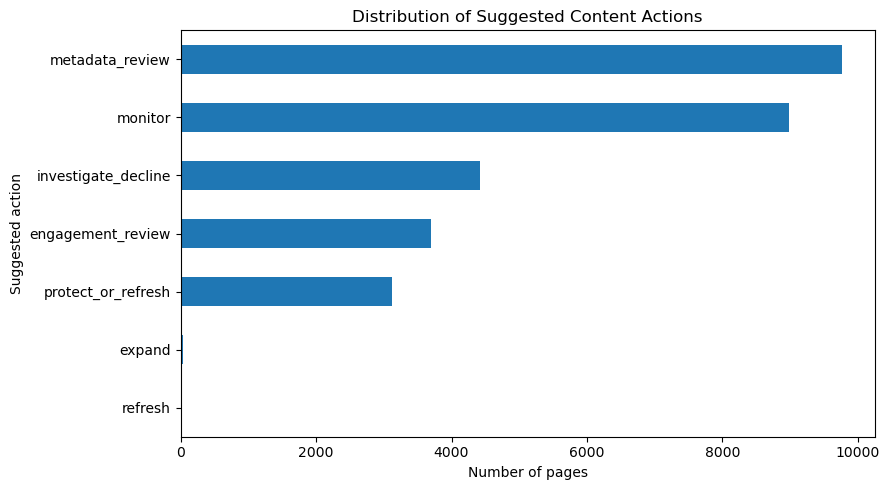

Saved: C:\Users\Ashok\Desktop\Mayur\internship-local-project\Internship-starter-flyrank\work\figures\action_distribution.png


In [17]:
action_counts = ranked_df["suggested_action"].value_counts().sort_values()

plt.figure(figsize=(9, 5))
action_counts.plot(kind="barh")
plt.xlabel("Number of pages")
plt.ylabel("Suggested action")
plt.title("Distribution of Suggested Content Actions")
plt.tight_layout()

action_figure_path = FIGURE_DIR / "action_distribution.png"
plt.savefig(action_figure_path, dpi=160, bbox_inches="tight")
plt.show()

print("Saved:", action_figure_path)

## Reason-code distribution

Reason codes make the queue auditable.

This figure shows which observable signals most often contribute to the current
review queue.

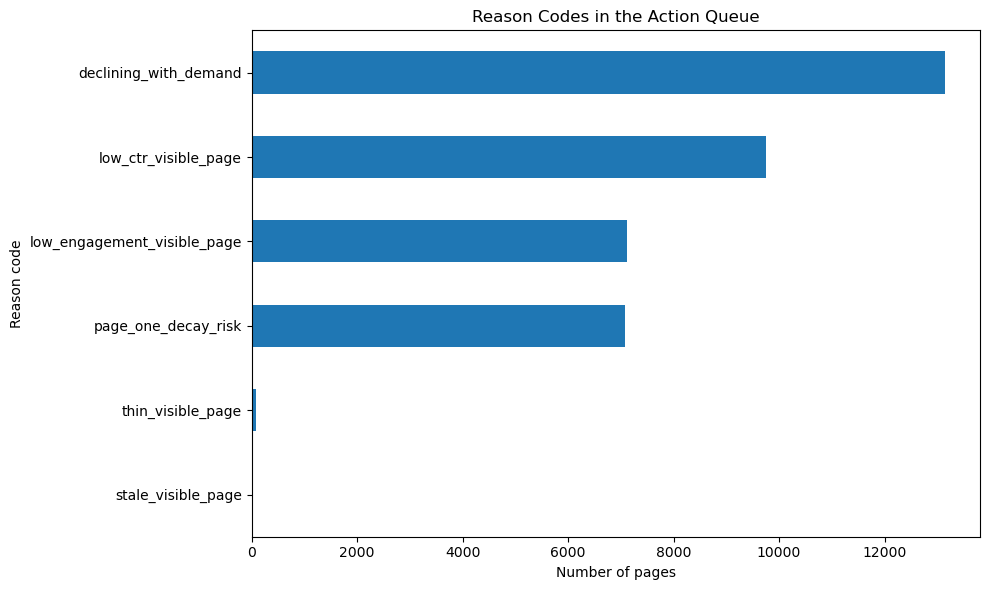

Saved: C:\Users\Ashok\Desktop\Mayur\internship-local-project\Internship-starter-flyrank\work\figures\reason_code_distribution.png


In [18]:
reason_counts_all = (
    ranked_df["reason_code_list"]
    .explode()
    .value_counts()
    .sort_values()
)

plt.figure(figsize=(10, 6))
reason_counts_all.plot(kind="barh")
plt.xlabel("Number of pages")
plt.ylabel("Reason code")
plt.title("Reason Codes in the Action Queue")
plt.tight_layout()

reason_figure_path = FIGURE_DIR / "reason_code_distribution.png"
plt.savefig(reason_figure_path, dpi=160, bbox_inches="tight")
plt.show()

print("Saved:", reason_figure_path)

# 5. Exports for the paper

The paper-facing queue should contain only public-safe information.

It should not contain:

- client names;
- domains;
- URLs;
- raw private queries;
- titles or raw content text;
- credentials;
- internal system details.

The queue can retain pseudonymized content IDs and aggregate/observable metrics
needed to explain the ranking.

The CSV is regenerated by the notebook and therefore does not need to be committed
to git.

In [19]:
preferred_columns = [
    "review_rank",
    "content_id",
    "final_refresh_score",
    "refresh_score",
    "score",
    "model_probability",
    "suggested_action",
    "reason_codes",
    "confidence",
    "human_review_flag",
    "impressions_90d",
    "sessions_90d",
    "content_age_days",
    "days_since_last_update",
    "trend_direction",
    "word_count",
    "avg_position",
    "ctr",
    "engagement_rate",
    "scroll_rate",
]

export_columns = [
    col for col in preferred_columns
    if col in ranked_df.columns
]

queue_export = ranked_df[export_columns].copy()

queue_export_path = OUTPUT_DIR / "content_action_queue.csv"

queue_export.to_csv(queue_export_path, index=False)

print("Exported queue:", queue_export_path)
print("Rows:", len(queue_export))
print("Columns:", len(queue_export.columns))

display(queue_export.head(10))

Exported queue: C:\Users\Ashok\Desktop\Mayur\internship-local-project\Internship-starter-flyrank\work\outputs\content_action_queue.csv
Rows: 30000
Columns: 16


,review_rank,content_id,suggested_action,reason_codes,confidence,human_review_flag,impressions_90d,sessions_90d,content_age_days,days_since_last_update,trend_direction,word_count,avg_position,ctr,engagement_rate,scroll_rate
0,1,content_304f48230142,investigate_decline,declining_with_demand,review_required,check_persistence,3803,17,187,20,down,3221.0,10.6,0.76,5.88,4.55
1,2,content_a1fb4e703a9e,investigate_decline,declining_with_demand,review_required,check_persistence,15320,9,445,25,down,2481.0,20.3,0.05,0.00,10.00
2,3,content_9aa793d4d895,investigate_decline,declining_with_demand,review_required,check_persistence,12581,11,141,20,down,3515.0,36.5,0.09,0.00,28.57
3,4,content_331d6c4de07b,metadata_review,page_one_decay_risk|low_ctr_visible_page|low_e...,review_required,check_before_change|check_position_context|che...,11751,78,463,22,stable,NaN,6.2,0.49,1.28,3.45
4,5,content_d99b7a2d90ca,engagement_review,declining_with_demand|low_engagement_visible_page,review_required,check_persistence|check_engagement_context,19140,145,263,14,down,2803.0,44.0,0.13,0.00,24.29
5,6,content_d4084a4bc775,metadata_review,declining_with_demand|low_ctr_visible_page,review_required,check_persistence|check_position_context,3970,5,147,20,down,3080.0,8.5,0.03,0.00,25.00
6,7,content_9a34b442b552,monitor,no_primary_reason,review_required,standard_review,20,1,90,20,down,3059.0,7.0,0.00,0.00,0.00
7,8,content_a63219c6e95a,monitor,no_primary_reason,review_required,standard_review,1724,28,445,22,stable,NaN,21.2,0.06,3.57,7.14
8,9,content_5e6c160719bc,engagement_review,declining_with_demand|low_engagement_visible_page,review_required,check_persistence|check_engagement_context,32574,68,90,20,down,3807.0,46.0,0.09,5.88,6.25
9,10,content_c27558df2b0c,metadata_review,declining_with_demand|page_one_decay_risk|low_...,review_required,check_persistence|check_before_change|check_po...,1240,3,257,104,down,NaN,4.9,0.16,0.00,0.00


## Action summary export

Alongside the ranked queue, export a small summary that can be reused in the
research paper.

This contains counts and shares rather than page-level content.

In [20]:
action_summary = (
    ranked_df["suggested_action"]
    .value_counts()
    .rename_axis("suggested_action")
    .reset_index(name="page_count")
)

action_summary["share"] = (
    action_summary["page_count"] / len(ranked_df)
)

action_summary_path = OUTPUT_DIR / "content_action_summary.csv"

action_summary.to_csv(action_summary_path, index=False)

display(action_summary)
print("Saved:", action_summary_path)

,suggested_action,page_count,share
0,metadata_review,9759,0.325300
1,monitor,8976,0.299200
2,investigate_decline,4416,0.147200
3,engagement_review,3695,0.123167
4,protect_or_refresh,3115,0.103833
5,expand,34,0.001133
6,refresh,5,0.000167


Saved: C:\Users\Ashok\Desktop\Mayur\internship-local-project\Internship-starter-flyrank\work\outputs\content_action_summary.csv


## Monitoring snapshot export

This file records the current state of the queue so future runs can be compared
against it.

It is a monitoring snapshot, not a claim that the model is permanently valid.

In [21]:
monitoring_export_path = OUTPUT_DIR / "action_playbook_monitoring.csv"

monitoring_table.to_csv(
    monitoring_export_path,
    index=False
)

print("Saved:", monitoring_export_path)

Saved: C:\Users\Ashok\Desktop\Mayur\internship-local-project\Internship-starter-flyrank\work\outputs\action_playbook_monitoring.csv


## Paper metrics

The metrics JSON records the key model-validation numbers that support the
recommendation section.

The numbers should remain traceable to the previous validation work.

The action-playbook notebook does not claim new model performance.

In [22]:
paper_metrics = {
    "lane": "Refresh / Content Opportunity Scoring",
    "validation_scope": "30,000-row anonymized starter slice",
    "validation_design": "client-holdout",
    "baseline_precision_at_50": 0.240,
    "logistic_regression_precision_at_50": 0.400,
    "decision_tree_precision_at_50": 0.540,
    "random_forest_precision_at_50": 0.740,
    "random_forest_roc_auc": 0.750,
    "random_forest_average_precision": 0.618,
    "interpretation": (
        "The random forest produced the strongest Precision@50 among the "
        "evaluated starter methods. This supports ranking usefulness on the "
        "evaluated slice, not guaranteed refresh outcomes."
    )
}

paper_metrics_path = OUTPUT_DIR / "action_playbook_metrics.json"

with open(paper_metrics_path, "w", encoding="utf-8") as f:
    json.dump(paper_metrics, f, indent=2)

print("Saved:", paper_metrics_path)

Saved: C:\Users\Ashok\Desktop\Mayur\internship-local-project\Internship-starter-flyrank\work\outputs\action_playbook_metrics.json


## Model / action card

The action card summarizes the intended use, evidence, limitations, and operating
rules in one compact artifact.

This is designed to be reusable when writing the recommendations section of the
research paper.

In [23]:
action_card = {
    "project": "Content Action Playbook",
    "lane": "Refresh / Content Opportunity Scoring",
    "purpose": "Prioritize pages for human review",
    "output": "Ranked review queue with suggested actions and reason codes",
    "best_validated_model": "Random forest",
    "validated_precision_at_50": 0.740,
    "validated_roc_auc": 0.750,
    "validated_average_precision": 0.618,
    "validation_scope": "30,000-row anonymized starter slice",
    "validation_design": "client-holdout",
    "intended_use": [
        "prioritize review candidates",
        "surface observable content-performance signals",
        "support limited review capacity"
    ],
    "not_intended_for": [
        "automatic publishing",
        "automatic deletion",
        "automatic merging",
        "causal claims",
        "search-engine algorithm claims",
        "client-facing decisions without human review"
    ],
    "human_review_required": True,
    "retrain_policy": (
        "Investigate material input/score/action drift or deteriorating "
        "future Precision@K before retraining and revalidating."
    )
}

action_card_path = OUTPUT_DIR / "action_playbook_card.json"

with open(action_card_path, "w", encoding="utf-8") as f:
    json.dump(action_card, f, indent=2)

print("Saved:", action_card_path)

Saved: C:\Users\Ashok\Desktop\Mayur\internship-local-project\Internship-starter-flyrank\work\outputs\action_playbook_card.json


## Export verification

The notebook should confirm that the expected paper-supporting files were created.

The queue itself is generated in `work/outputs/`.

Reusable figures are stored in `work/figures/`.

In [24]:
expected_outputs = [
    queue_export_path,
    action_summary_path,
    monitoring_export_path,
    paper_metrics_path,
    action_card_path,
]

for path in expected_outputs:
    print(f"{path.name}: {'OK' if path.exists() else 'MISSING'}")

print("\nFigures:")
for path in [action_figure_path, reason_figure_path]:
    print(f"{path.name}: {'OK' if path.exists() else 'MISSING'}")

content_action_queue.csv: OK
content_action_summary.csv: OK
action_playbook_monitoring.csv: OK
action_playbook_metrics.json: OK
action_playbook_card.json: OK

Figures:
action_distribution.png: OK
reason_code_distribution.png: OK


## Cost / value thinking

The queue should be interpreted under limited review capacity.

A high-scoring page is not automatically the highest-value page to change.

A practical reviewer should consider:

- expected business relevance;
- amount of observable demand/exposure;
- strength of the evidence;
- estimated effort to make the change;
- risk of making the change;
- whether the action is reversible;
- whether another page or issue should be addressed first.

### Simple prioritization principle

A useful action has:

> meaningful observable opportunity + reasonable evidence + feasible effort +
> acceptable risk.

This means a lower-ranked page can sometimes be more attractive than a
higher-ranked page if its recommended action is much easier, safer, or more
valuable.

The model score should therefore prioritize attention, while human judgment
determines actual value.

In [25]:
# Simple descriptive value proxy for review prioritization.
# This is NOT a predicted ROI or financial value.

value_df = ranked_df.copy()

if "impressions_90d" in value_df.columns:
    value_df["exposure_scale"] = np.log1p(
        value_df["impressions_90d"].clip(lower=0)
    )
else:
    value_df["exposure_scale"] = 0

if score_col is not None and score_col in value_df.columns:
    score_numeric = pd.to_numeric(
        value_df[score_col],
        errors="coerce"
    ).fillna(0)

    score_range = score_numeric.max() - score_numeric.min()

    if score_range > 0:
        normalized_score = (
            score_numeric - score_numeric.min()
        ) / score_range
    else:
        normalized_score = 0
else:
    normalized_score = 0

value_df["review_value_proxy"] = (
    0.70 * normalized_score
    + 0.30 * (
        value_df["exposure_scale"]
        / max(value_df["exposure_scale"].max(), 1)
    )
)

print(
    "Important: review_value_proxy is a prioritization aid, "
    "not financial ROI."
)

display(
    value_df[
        [
            "review_rank",
            "suggested_action",
            "review_value_proxy"
        ]
    ].head(20)
)

Important: review_value_proxy is a prioritization aid, not financial ROI.


,review_rank,suggested_action,review_value_proxy
0,1,investigate_decline,0.187969
1,2,investigate_decline,0.219735
2,3,investigate_decline,0.215244
3,4,metadata_review,0.213688
4,5,engagement_review,0.224811
5,6,metadata_review,0.188949
6,7,monitor,0.069419
7,8,monitor,0.169937
8,9,engagement_review,0.236934
9,10,metadata_review,0.162429


## Decay / refresh insight

One practical pattern in the queue is the combination of:

- content age,
- freshness,
- existing visibility,
- and movement/decline signals.

A page can be worth reviewing when it still has meaningful exposure but also shows
evidence of age or weakening performance.

The important interpretation is:

> older visible content with weakening signals can be a useful refresh-review
> candidate.

This is a prioritization insight, not proof that age caused the decline.

The reviewer should also check seasonality, consolidation, SERP changes, and noise
before approving a refresh.

The `page_one_decay_risk` and `stale_visible_page` reason codes make this pattern
visible in the queue.

In [26]:
decay_reasons = {
    "page_one_decay_risk": int(
        ranked_df["reason_code_list"]
        .apply(lambda x: "page_one_decay_risk" in x)
        .sum()
    ),
    "stale_visible_page": int(
        ranked_df["reason_code_list"]
        .apply(lambda x: "stale_visible_page" in x)
        .sum()
    ),
    "declining_with_demand": int(
        ranked_df["reason_code_list"]
        .apply(lambda x: "declining_with_demand" in x)
        .sum()
    ),
}

decay_summary = pd.DataFrame(
    list(decay_reasons.items()),
    columns=["decay_related_reason", "page_count"]
)

display(decay_summary)

,decay_related_reason,page_count
0,page_one_decay_risk,7076
1,stale_visible_page,17
2,declining_with_demand,13152


# Self-check

Before submission, confirm:

- [x] Every section is filled with markdown thinking and supporting code.
- [ ] The notebook runs top to bottom with no errors.
- [x] The queue is treated as decision-support, not automatic action.
- [x] Reason codes explain why a page was ranked.
- [x] Suggested actions are review recommendations.
- [x] Human review is mandatory before acting.
- [x] A clear no-go list is included.
- [x] Monitoring and retrain triggers are defined.
- [x] The decay/refresh insight is included.
- [x] Cost/value thinking is included.
- [x] The ranked queue is exported to `work/outputs/`.
- [x] Reusable figures are exported to `work/figures/`.
- [x] No client names, URLs, private queries, domains, or raw content text are included.
- [x] Claims use careful language such as observed, measured, directional, and decision-support.
- [ ] The executed notebook is committed under `work/notebooks/w07_action_playbook.ipynb`.
- [ ] The repository URL is ready for submission.